In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy.interpolate import make_interp_spline

In [ ]:
df = pd.read_csv("rhfs.csv")
# count properties per owner

df.dropna(inplace=True)

In [ ]:

# --- 1. Data prep ---
bins = [1, 6, 11, 26, 51, 101, 201, 301, 401, 501, 1001, 2001, 3000]
labels = ["1 unit", "2–5 units", "6–10", "11–25", "26–50", "51–100", 
          "101–200", "201–300", "301–400", "401–500", "501–1,000", "1,001+"]

rents = df[['NUMUNITS_R']].copy()
rents.rename(columns={'NUMUNITS_R': 'num_units'}, inplace=True)

rents['unit_bin'] = pd.cut(
    rents['num_units'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

C:\Users\Ben\AppData\Local\Temp\ipykernel_27264\3684710802.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


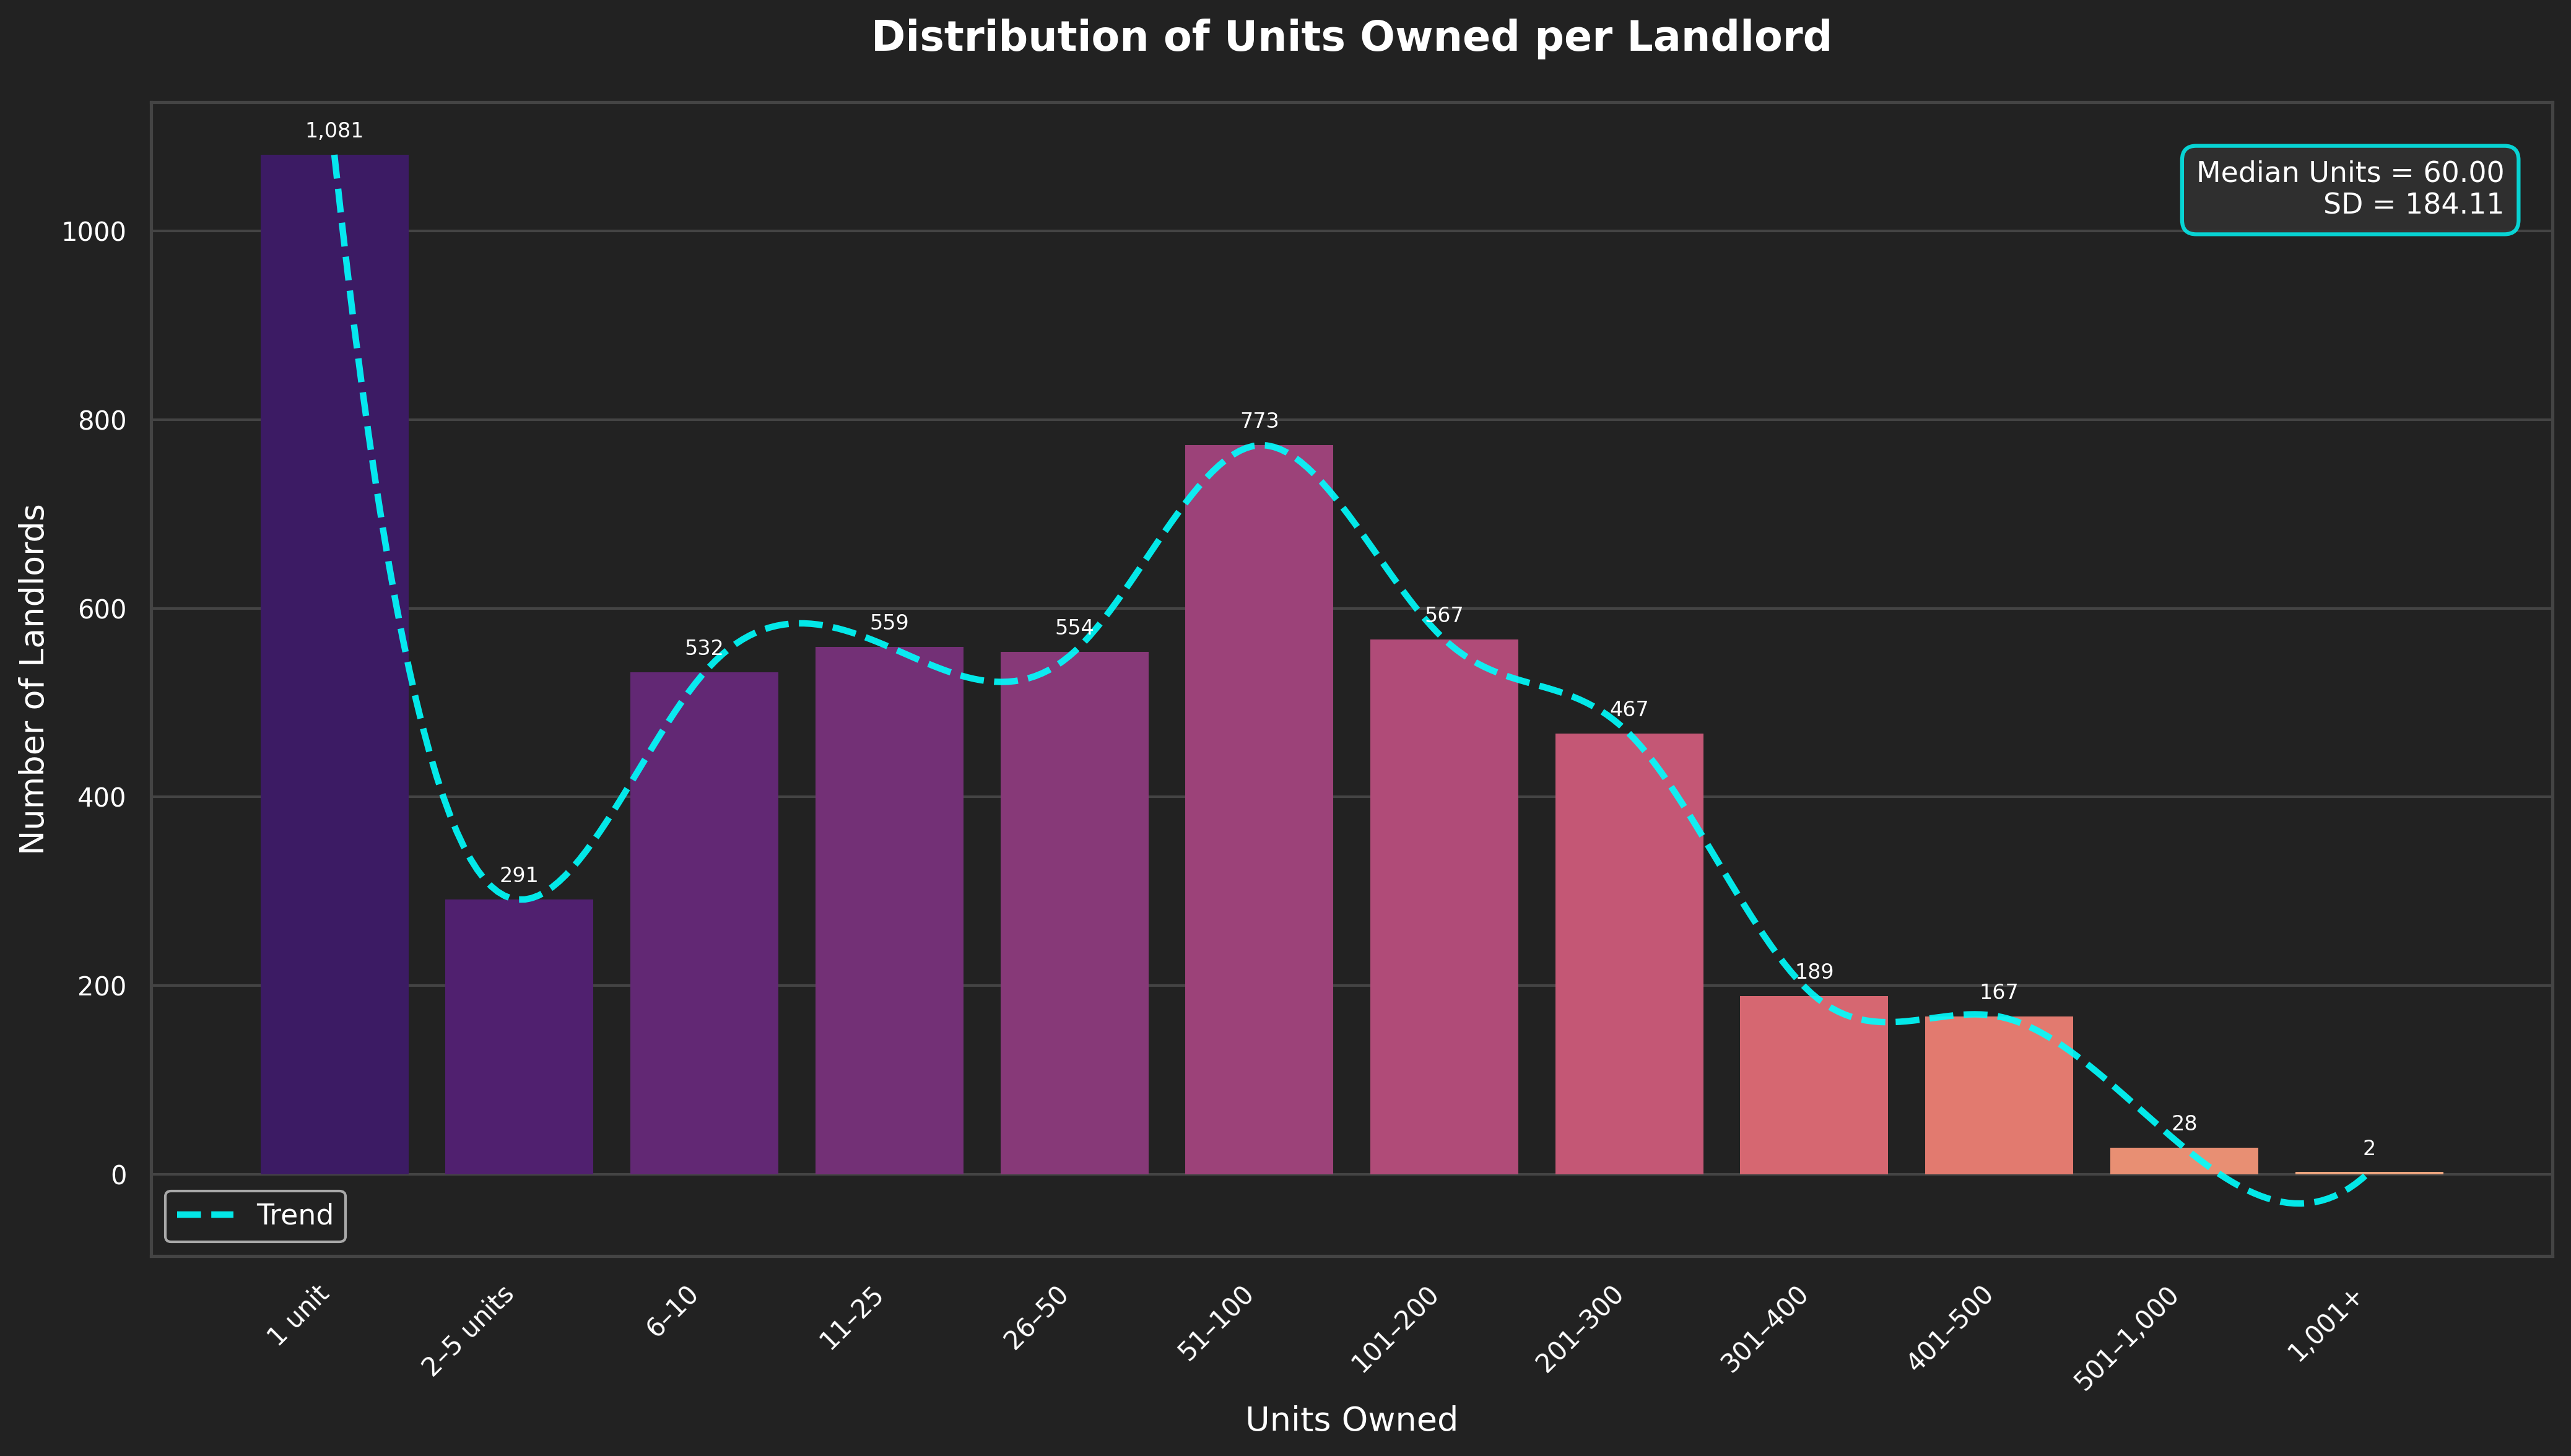

In [ ]:

# --- 2. Plot setup ---
plt.figure(figsize=(14, 8), dpi=300)

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#222222",
    "figure.facecolor": "#222222",
    "axes.edgecolor": "#444444",
    "grid.color": "#444444",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "font.family": "DejaVu Sans"
})

x_labels = bin_counts.index
x_numeric = np.arange(len(x_labels))
y_values = bin_counts.values

# --- 3. Magma colors (fixed warning!) ---
cmap = plt.get_cmap("magma")
colors = list(cmap(np.linspace(0.2, 0.8, len(x_labels))))  # Convert to list()

# --- 4. Bars ---
ax = sns.barplot(
    x=x_numeric,
    y=y_values,
    palette=colors,
    edgecolor="none",      # REMOVE white border!
    legend=False
)

# Bar labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=8,
        color='white',
        xytext=(0, 5),
        textcoords='offset points'
    )

# --- 5. Smooth trend line ---
x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 300)
spline = make_interp_spline(x_numeric, y_values, k=3)
y_smooth = spline(x_smooth)

plt.plot(x_smooth, y_smooth, color="cyan", linewidth=2.5, linestyle="--", alpha=0.9, label="Trend")

# --- 6. Annotations ---
median_units = rents['num_units'].median()
std_units = rents['num_units'].std()

ax.text(
    0.98, 0.95,
    f"Median Units = {median_units:.2f}\nSD = {std_units:.2f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(boxstyle="round,pad=0.5", fc="#333333", ec="cyan", lw=1.5, alpha=0.8)
)

# --- 7. Final labels ---
plt.xlabel("Units Owned", fontsize=13, color='white')
plt.ylabel("Number of Landlords", fontsize=13, color='white')
plt.title("Distribution of Units Owned per Landlord", fontsize=16, weight='bold', color='white', pad=20)

plt.xticks(
    ticks=x_numeric,
    labels=x_labels,
    rotation=45,
    ha='right',
    fontsize=10,
    color='white'
)
plt.yticks(fontsize=10, color='white')

plt.legend()
plt.tight_layout()
plt.show()